### Random Forest Model

#### Elizabeth Greenan

In [1]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tabulate import tabulate

In [2]:
# Read in CSV files from pre-processing
x_train_scaled = pd.read_csv("../Data/x_train.csv")
x_test_scaled = pd.read_csv("../Data/x_test.csv")
y_train = pd.read_csv("../Data/y_train.csv")
y_test = pd.read_csv("../Data/y_test.csv")

In [3]:
# Check that data loaded in (commented out since it was confirmed)
# x_train_scaled.head()
# x_test_scaled.head()
# y_train.head()
# y_test.head()

In [4]:
# Drop columns from dimension reductionality

dimension_reduction_col = ['Age_Category_Elderly', 'Age_Category_Young_Adult', 'Education_College_4_years_or_more_(college_graduate)', 'Has_Disability', 'Marital_Status_Married']

x_train_scaled = x_train_scaled.drop(columns = dimension_reduction_col)
x_test_scaled = x_test_scaled.drop(columns = dimension_reduction_col)

In [5]:
# Check data shape to ensure there are now only 99 variables
print(y_train.shape)
print(y_test.shape)
print(x_train_scaled.shape)
print(x_test_scaled.shape)

(352682, 1)
(72237, 1)
(352682, 99)
(72237, 99)


In [6]:
# Since Random Forest needs the response variable to be in a 1D array, .squeeze() was applied to both y_test and y_train
# Source: https://www.geeksforgeeks.org/python/numpy-squeeze-in-python/
y_train = y_train.squeeze()
y_test = y_test.squeeze()

# Confirm they are now in a 1D array
print(y_train.shape)
print(y_test.shape)

(352682,)
(72237,)


## Cross-Validation

In [7]:
# Run Random Forest model and cross-validation
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html
# Source: https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter

random_forest_model = RandomForestClassifier(n_estimators = 100, n_jobs = -1, random_state = 123) # n_jobs = -1 uses all processors, improving speed

f1_scores = cross_val_score(
    random_forest_model,
    x_train_scaled,
    y_train,
    cv = 5, # 5 folds is the default number of cross-validation k-folds
    scoring = 'f1') # Target variable is binary, so F1-Score was chosen

# Create table of above results that can go in the report
f1_cross_validation_results = [
    ["Cross-Validation F1-Scores:", np.round(f1_scores, 4)],
    ["Mean Cross-Validation F1-Score:", round(f1_scores.mean(), 4)],
    ["Standard Deviation Cross-Validation F1-Score:", round(f1_scores.std(), 4)]
]
recall_scores = cross_val_score(
    random_forest_model,
    x_train_scaled,
    y_train,
    cv = 5, # 5 folds is the default number of cross-validation k-folds
    scoring = 'recall') # Decided to also check recall

# Create table of above results that can go in the report
recall_cross_validation_results = [
    ["Cross-Validation Recall:", np.round(recall_scores, 4)],
    ["Mean Cross-Validation Recall", round(recall_scores.mean(), 4)],
    ["Standard Deviation Cross-Validation Recall:", round(recall_scores.std(), 4)]
]

print(tabulate(f1_cross_validation_results, headers = ['Evaluation Metric', 'Value'], tablefmt = 'fancy_grid', showindex = False))

print(tabulate(recall_cross_validation_results, headers = ['Evaluation Metric', 'Value'], tablefmt = 'fancy_grid', showindex = False))

random_forest_model.fit(x_train_scaled, y_train)



╒═══════════════════════════════════════════════╤══════════════════════════════════════╕
│ Evaluation Metric                             │ Value                                │
╞═══════════════════════════════════════════════╪══════════════════════════════════════╡
│ Cross-Validation F1-Scores:                   │ [0.001  0.002  0.001  0.0025 0.002 ] │
├───────────────────────────────────────────────┼──────────────────────────────────────┤
│ Mean Cross-Validation F1-Score:               │ 0.0017                               │
├───────────────────────────────────────────────┼──────────────────────────────────────┤
│ Standard Deviation Cross-Validation F1-Score: │ 0.0006                               │
╘═══════════════════════════════════════════════╧══════════════════════════════════════╛
╒═════════════════════════════════════════════╤══════════════════════════════════════╕
│ Evaluation Metric                           │ Value                                │
╞════════════════════════

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [8]:
# Source: https://scikit-learn.org/stable/modules/model_evaluation.html#accuracy-score
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

# Make predictions
y_pred = random_forest_model.predict(x_test_scaled)

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Create table of above results that can go in the report

evaluation_metrics = [
    ["Accuracy:", round(accuracy, 4)],
    ["Precision:", round(precision, 4)],
    ["Recall:", round(recall, 4)],
    ["F1-Score:", round(f1, 4)]
]

print(tabulate(evaluation_metrics, headers = ['Evaluation Metric', 'Value'], tablefmt = 'fancy_grid', showindex = False))

╒═════════════════════╤═════════╕
│ Evaluation Metric   │   Value │
╞═════════════════════╪═════════╡
│ Accuracy:           │  0.9413 │
├─────────────────────┼─────────┤
│ Precision:          │  0.6    │
├─────────────────────┼─────────┤
│ Recall:             │  0.0007 │
├─────────────────────┼─────────┤
│ F1-Score:           │  0.0014 │
╘═════════════════════╧═════════╛


In [9]:
# Calculate the number of unique values in our response variable, highlighting class imbalance, which is affecting results
y_train.value_counts()

E_Cig_User
0.0    332416
1.0     20266
Name: count, dtype: int64

## Confusion Matrix

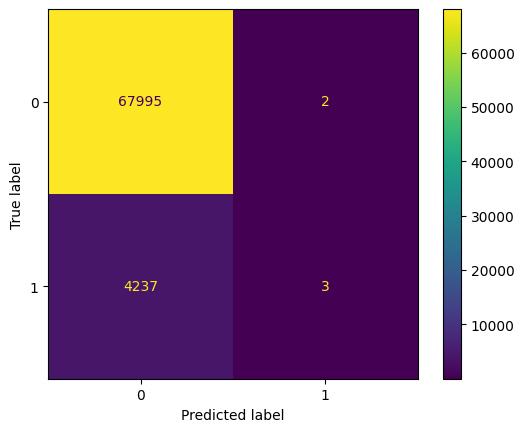

In [10]:
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm)
disp.plot()
plt.show()

## ROC Curve & AUC

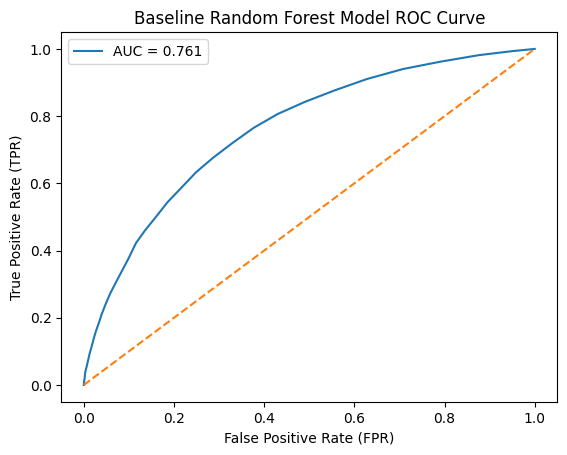

In [11]:
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html
# Source: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_auc_score.html
# Source: https://www.geeksforgeeks.org/machine-learning/auc-roc-curve/

y_prob = random_forest_model.predict_proba(x_test_scaled)[:,1] # Calculate probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_prob) # Calculate the ROC Curve
auc_score = roc_auc_score(y_test, y_prob) # Calculate the AUC Score

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label = f"AUC = {round(auc_score, 3)}")
plt.plot([0,1],[0,1], '--')

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Baseline Random Forest Model ROC Curve")
plt.legend()
plt.show()

## Feature Importance

In [12]:
# Source: https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance.html
# Source: https://www.geeksforgeeks.org/machine-learning/feature-importance-with-random-forests/

importances = random_forest_model.feature_importances_
feature_names = x_train_scaled.columns

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Gini Importance": importances}).sort_values("Gini Importance", ascending = False)
feature_importance.head(10) # Show the first 10 features, which have the highest importance

,Feature,Gini Importance
0,BMI,0.079438
10,Total_Drinks_30_days,0.060057
14,Sugar_Soda_Drinks_Per_Month,0.055267
13,Sugar_Soda_Drinks_Per_Week,0.048085
17,Non_Soda_Sugar_Drinks_Per_Month,0.044619
16,Non_Soda_Sugar_Drinks_Per_Week,0.034926
7,Number_of_Days_Last_Month_Poor_Health,0.033066
12,Sugar_Soda_Drinks_Per_Day,0.031261
15,Non_Soda_Sugar_Drinks_Per_Day,0.030940
5,Marijuana_Use_30_Days,0.026502


In [13]:
# Print the first 10 features as a cleaner table for the report
print(tabulate(feature_importance.head(10), headers = 'keys', tablefmt = 'fancy_grid', showindex = False))

╒═══════════════════════════════════════╤═══════════════════╕
│ Feature                               │   Gini Importance │
╞═══════════════════════════════════════╪═══════════════════╡
│ BMI                                   │         0.0794378 │
├───────────────────────────────────────┼───────────────────┤
│ Total_Drinks_30_days                  │         0.0600568 │
├───────────────────────────────────────┼───────────────────┤
│ Sugar_Soda_Drinks_Per_Month           │         0.0552671 │
├───────────────────────────────────────┼───────────────────┤
│ Sugar_Soda_Drinks_Per_Week            │         0.0480849 │
├───────────────────────────────────────┼───────────────────┤
│ Non_Soda_Sugar_Drinks_Per_Month       │         0.0446194 │
├───────────────────────────────────────┼───────────────────┤
│ Non_Soda_Sugar_Drinks_Per_Week        │         0.0349259 │
├───────────────────────────────────────┼───────────────────┤
│ Number_of_Days_Last_Month_Poor_Health │         0.0330663 │
├───────

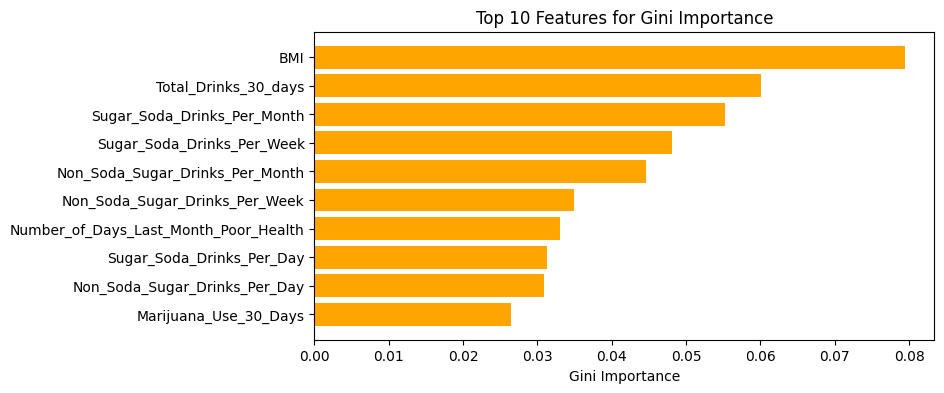

In [14]:
# Plot the top 10 features
top_10_features = feature_importance.head(10)

plt.figure(figsize= (8,4))
plt.barh(top_10_features["Feature"], top_10_features["Gini Importance"], color = 'orange')
plt.xlabel('Gini Importance')
plt.title('Top 10 Features for Gini Importance')
plt.gca().invert_yaxis() # Inverts y-axis so they are in descending order
plt.show()